In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from matplotlib import font_manager as fm
import os
font_path = "times.ttf"  # Path to the font file on root

if os.path.exists(font_path):
    # Add the file to Matplotlib's internal font registry
    fm.fontManager.addfont(font_path)
    # Extract the precise font family name from the file
    prop = fm.FontProperties(fname=font_path)

    # Apply globally to Matplotlib
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"
    plt.rcParams["axes.titleweight"] = "bold"
else:
    print(f"Warning: {font_path} not found. Using default font.")

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1851s 11us/step
Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

Image successfully saved as 'cifar10_classes_grid.eps' with 600 DPI.


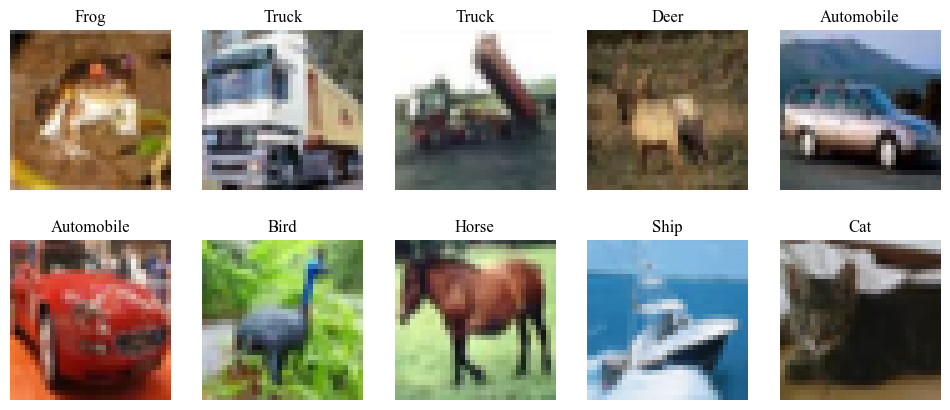

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.savefig("cifar10_classes_grid.eps", format="eps", dpi=600)
print("Image successfully saved as 'cifar10_classes_grid.eps' with 600 DPI.")

plt.show()

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = layers.Input(shape=(32, 32, 3))

x = layers.Resizing(224, 224)(inputs)

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [ ]:
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.3816 - loss: 1.7664

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.savefig("train_and_valid_acc.eps", format="eps", dpi=600)
print("Image successfully saved as 'train_and_valid_acc.eps' with 600 DPI.")